In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
import warnings

# Configuración visual para gráficos más profesionales
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
warnings.filterwarnings('ignore')

In [2]:
drive.mount('/content/drive')
PATH = '/content/drive/My Drive/Experimentos/data/'
file_path = f'{PATH}mdt_weather_forecasting_eje.parquet'

Mounted at /content/drive


In [7]:
print(f"Cargando datos desde: {file_path}...")
df = pd.read_parquet(file_path)

Cargando datos desde: /content/drive/My Drive/Experimentos/data/mdt_weather_forecasting_eje.parquet...


In [8]:
def optimize_memory(df):
    """
    Reduce el consumo de memoria ajustando tipos de datos.
    """
    print(f"Memoria inicial: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # 1. Optimizar Categóricos (Estaciones)
    if 'estacion' in df.columns:
        df['estacion'] = df['estacion'].astype('category')

    # 2. Optimizar Flotantes (Reducir de 64 a 32 bits)
    # Los datos climáticos no requieren precisión de 64 bits para predicción
    cols_float = df.select_dtypes(include=['float64']).columns
    for col in cols_float:
        df[col] = pd.to_numeric(df[col], downcast='float')

    print(f"Memoria optimizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df

# Ejecutar optimización
df = optimize_memory(df)

Memoria inicial: 199.40 MB
Memoria optimizada: 104.15 MB


## FASE 1: Estructuración Topológica
### Paso 0: Inyección del Esqueleto Temporal Continuo
Las series temporales en el mundo real sufren de "apagones" (dataloggers desconectados) donde las filas enteras desaparecen en lugar de registrar un `NaN`. Antes de imputar, es obligatorio generar una matriz de tiempo continua perfecta (hora a hora) cruzada con todas las estaciones, y hacer un *left merge* con los datos reales para exponer todos los huecos estructurales de la red REMMAQ.

In [9]:
from itertools import product

def inyectar_esqueleto_temporal(df_raw, fecha_corte='2008-01-01'):
    """
    Fuerza la continuidad temporal de la base de datos cruzando un vector
    de tiempo perfecto con el universo de estaciones.
    """
    print("="*80)
    print(" ️ FASE 1 (PASO 0): INYECCIÓN DEL ESQUELETO TEMPORAL CONTINUO")
    print("="*80)

    filas_antes = len(df_raw)
    nulos_antes = df_raw['temperaturaMedia'].isnull().sum()

    #********************************************************
    # CORTE: TOMAMOS DESDE 2008 DEBIDO A FALTANTES DE radiacionSolar
    #********************************************************

    df_raw = df_raw[df_raw['fechaHora'] >= fecha_corte]

    # 1. Identificar límites temporales absolutos y estaciones activas
    min_fecha = df_raw['fechaHora'].min()
    max_fecha = df_raw['fechaHora'].max()
    estaciones_unicas = df_raw['estacion'].unique()


    print(f"Rango temporal de la red: {min_fecha}  ->  {max_fecha}")
    print(f"Total de nodos (estaciones): {len(estaciones_unicas)}")

    # 2. Crear el vector de tiempo perfecto (frecuencia de 1 hora)
    # Nota: Usamos 'h' como alias de hora compatible con las versiones recientes de Pandas
    vector_tiempo = pd.date_range(start=min_fecha, end=max_fecha, freq='h')

    # 3. Producto cartesiano: Todas las horas perfectas para todas las estaciones
    esqueleto = pd.DataFrame(
        list(product(vector_tiempo, estaciones_unicas)),
        columns=['fechaHora', 'estacion']
    )

    # 4. Cruzar el esqueleto con la realidad imperfecta (Left Merge)
    df_denso = pd.merge(esqueleto, df_raw, on=['fechaHora', 'estacion'], how='left')

    # 5. Reconstruir metadatos temporales básicos que quedaron vacíos en las filas nuevas
    df_denso['fecha'] = df_denso['fechaHora'].dt.date
    # Aseguramos que 'hora' sea estrictamente numérica para los filtros posteriores
    df_denso['hora'] = df_denso['fechaHora'].dt.hour
    df_denso['mes'] = df_denso['fechaHora'].dt.month
    df_denso['anio'] = df_denso['fechaHora'].dt.year
    df_denso['dia_semana'] = df_denso['fechaHora'].dt.dayofweek

    # Asegurar que la categoría se mantenga tras el merge
    df_denso['estacion'] = df_denso['estacion'].astype('category')

    filas_despues = len(df_denso)
    nulos_despues = df_denso['temperaturaMedia'].isnull().sum()

    print("\nResultados de la Inyección Estructural:")
    print(f"  Filas originales reportadas: {filas_antes:,}")
    print(f"  Filas matemáticas reales:    {filas_despues:,} (+{filas_despues - filas_antes:,} huecos expuestos)")
    print(f"  Nulos en Temp (Antes):       {nulos_antes:,}")
    print(f"  Nulos en Temp (Después):     {nulos_despues:,} (+{nulos_despues - nulos_antes:,} fallos eléctricos sincerados)")

    return df_denso

# Ejecutamos la inyección para destapar los nulos
df = inyectar_esqueleto_temporal(df)

 🕰️ FASE 1 (PASO 0): INYECCIÓN DEL ESQUELETO TEMPORAL CONTINUO
Rango temporal de la red: 2008-01-01 00:00:00  ->  2026-03-31 23:00:04
Total de nodos (estaciones): 6

Resultados de la Inyección Estructural:
 ➔ Filas originales reportadas: 1,125,813
 ➔ Filas matemáticas reales:    959,760 (+-166,053 huecos expuestos)
 ➔ Nulos en Temp (Antes):       13,492
 ➔ Nulos en Temp (Después):     51,430 (+37,938 fallos eléctricos sincerados)


### Fundamentación Metodológica

En las redes de monitoreo ambiental del mundo real, la interrupción del suministro eléctrico en los *dataloggers* produce una **pérdida silenciosa de información**: la fila desaparece por completo en lugar de registrar un valor `NaN`.

* **La decisión metodológica:** Ejecutar un producto cartesiano entre un vector de tiempo continuo perfecto (con un $\Delta t$ constante de 1 hora) y el universo de estaciones.
* **Justificación Matemática:** El modelamiento de series temporales —independientemente de si se consumen mediante ensambles de árboles (XGBoost), modelos estadísticos o arquitecturas Deep Learning— descansa sobre el supuesto de **equidistancia estricta**. Omitir este paso provocaría que los operadores de retardo (como la función `shift(1)`) emparejen, por ejemplo, las 14:00 del lunes con las 09:00 del martes como si fueran los instantes consecutivos $t$ y $t+1$. Esto corrompería el espacio de características (*Feature Space*) y el cálculo de la inercia térmica. La operación destapó **44,331 horas de fallos ocultos**, sincerando la topología de la red para el motor de imputación.

## FASE 2: Poda y Filtros Físicos (Protocolo QA/QC REMMAQ)
Aplicamos los límites termodinámicos descubiertos en el EDA para evitar que los *outliers* de *hardware* contaminen a nuestro imputador multivariado:
1. **Amputación de Ozono:** Eliminación por censura histórica (87% de nulos).
2. **Filtro Barométrico:** Se anulan presiones $< 700\text{ hPa}$ (físicamente imposibles en Quito).
3. **Techo Solar:** Se anulan picos parásitos $> 1400\text{ W/m}^2$.
4. **Falsos Ceros:** Se cazan sensores de radiación caídos o trabados entre las 09:00 y las 15:00.

In [10]:
def aplicar_filtros_fisicos_qaqc(df_denso):
    """
    Limpia los valores que violan las leyes de la física atmosférica de Quito
    antes de pasarlos al motor de imputación.
    """
    print("="*80)
    print("  FASE 2: PODA Y FILTROS FÍSICOS (QA/QC DE LA REMMAQ)")
    print("="*80)

    df_clean = df_denso.copy()

    # 1. Eliminación de Ozono (Censura histórica)
    if 'ozono' in df_clean.columns:
        df_clean = df_clean.drop(columns=['ozono'])
        print("  [Filtro 1] Columna 'ozono' amputada definitivamente (censura histórica).")

    # 2. Filtro Barométrico (Altitud de Quito: 2800m -> ~725 hPa)
    if 'presionBarometrica' in df_clean.columns:
        fallos_presion = (df_clean['presionBarometrica'] < 700).sum()
        df_clean.loc[df_clean['presionBarometrica'] < 700, 'presionBarometrica'] = np.nan
        print(f"  [Filtro 2] Presión < 700 hPa neutralizada: {fallos_presion:,} registros a NaN.")

    # 3. Techo Solar Físico (Constante solar máxima ~1361 W/m2)
    if 'radiacionSolar' in df_clean.columns:
        fallos_solar = (df_clean['radiacionSolar'] > 1400).sum()
        df_clean.loc[df_clean['radiacionSolar'] > 1400, 'radiacionSolar'] = np.nan
        print(f"  [Filtro 3] Radiación > 1400 W/m² neutralizada: {fallos_solar:,} picos parásitos a NaN.")

    # 4. Caza de Sensores Muertos (Falsos ceros diurnos)
    if 'radiacionSolar' in df_clean.columns:
        # Entre las 09:00 y las 15:00 es imposible que haya 0 W/m2 de radiación en el ecuador
        horas_diurnas = (df_clean['hora'] >= 9) & (df_clean['hora'] <= 15)
        sensor_muerto = horas_diurnas & (df_clean['radiacionSolar'] <= 5)

        fallos_ceros = sensor_muerto.sum()
        df_clean.loc[sensor_muerto, 'radiacionSolar'] = np.nan
        print(f"  [Filtro 4] Falsos ceros diurnos neutralizados: {fallos_ceros:,} sensores apagados a NaN.")

    print("\n Fase 2 completada. Base de datos libre de violaciones físicas.")
    return df_clean

# Ejecutamos la limpieza física
df = aplicar_filtros_fisicos_qaqc(df)

 🧹 FASE 2: PODA Y FILTROS FÍSICOS (QA/QC DE LA REMMAQ)
 ➔ [Filtro 1] Columna 'ozono' amputada definitivamente (censura histórica).
 ➔ [Filtro 2] Presión < 700 hPa neutralizada: 93 registros a NaN.
 ➔ [Filtro 3] Radiación > 1400 W/m² neutralizada: 0 picos parásitos a NaN.
 ➔ [Filtro 4] Falsos ceros diurnos neutralizados: 1,180 sensores apagados a NaN.

🚀 Fase 2 completada. Base de datos libre de violaciones físicas.


### Fundamentación Metodológica

Se traza una frontera estricta entre el *Outlier Estadístico* (fenómeno climático extremo, que debe preservarse) y el *Outlier Físico* (ruido de hardware, que debe destruirse):

1. **Amputación de Ozono (`ozono`):** Presentó un **87.4% de valores faltantes por censura histórica** (el sensor no existía en la red antigua). Imputar matemáticamente más de una década de datos inventaría la covarianza de la serie.
2. **Filtro Barométrico ($< 700\text{ hPa}$):** A $2,800\text{ m.s.n.m.}$, la presión atmosférica media de Quito es de $\approx 725\text{ hPa}$. Una caída por debajo de 700 hPa implicaría que la estación se desplazó a la altitud de la cima del volcán Cotopaxi; constituye un error de membrana del barómetro.
3. **Falsos Ceros Diurnos (`radiacionSolar`):** Se neutralizan a `NaN` los registros de $0\text{ W/m}^2$ detectados entre las 09:00 y las 15:00. Físicamente es imposible la ausencia de fotones en el ecuador terrestre a mediodía; el sensor se encontraba cubierto o en cortocircuito.
4. **Techo de Irradiancia ($> 1400\text{ W/m}^2$):** Se purgan micro-picos eléctricos que superan la constante solar en el tope de la atmósfera terrestre ($\approx 1361\text{ W/m}^2$).

## FASE 3: Motor de Imputación Híbrido
Dado el comportamiento diferenciado de las variables atmosféricas, se aplican tres estrategias matemáticas distintas para reconstruir la matriz sin inventar física falsa:

1. **Rescate Astronómico (`radiacionSolar`):** Imputación determinista basada en la topografía solar (mediana histórica por `estación`, `mes` y `hora`).
2. **Descomposición Vectorial del Viento:** Transformación de la magnitud y dirección (grados) en componentes ortogonales ($U$, $V$) para habilitar la regresión lineal espacial.
3. **Imputación Topológica Espacial (Bayesian Ridge):** Para temperatura, humedad, presión y viento. Pivoteamos la base para que las estaciones actúen como columnas. Si la estación A se apaga, las estaciones B, C y D en ese mismo instante $t$ usarán un modelo Bayesiano para reconstruir el dato perdido.
4. **Planchado Lineal:** Cierre de micro-huecos (máximo 3 horas) que hayan quedado tras los pasos anteriores.

In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import math

def motor_imputacion_hibrido(df_clean):
    print("="*80)
    print(" ️ FASE 3: MOTOR DE IMPUTACIÓN HÍBRIDO (ESPACIO-TEMPORAL)")
    print("="*80)

    df_imp = df_clean.copy()

    # -------------------------------------------------------------------------
    # PASO 3.1: Rescate Astronómico (Radiación Solar)
    # -------------------------------------------------------------------------
    if 'radiacionSolar' in df_imp.columns:
        nulos_sol_antes = df_imp['radiacionSolar'].isnull().sum()

        # Imputación por estacionalidad (Mes) y ciclo diurno (Hora) por Estación
        df_imp['radiacionSolar'] = df_imp['radiacionSolar'].fillna(
            df_imp.groupby(['estacion', 'mes', 'hora'], observed=True)['radiacionSolar'].transform('median')
        )
        # Fallback por si hay un hueco absoluto en un mes entero para una estación
        df_imp['radiacionSolar'] = df_imp['radiacionSolar'].fillna(
            df_imp.groupby(['mes', 'hora'])['radiacionSolar'].transform('median')
        )

        nulos_sol_despues = df_imp['radiacionSolar'].isnull().sum()
        print(f"  [3.1] Radiación Solar: {nulos_sol_antes - nulos_sol_despues:,} nulos rescatados por astronomía.")

    # -------------------------------------------------------------------------
    # PASO 3.2: Descomposición Vectorial del Viento (Pre-requisito Bayesiano)
    # -------------------------------------------------------------------------
    if 'velocidadViento' in df_imp.columns and 'direccionViento' in df_imp.columns:
        print(f"  [3.2] Descomponiendo Viento Polar a Cartesiano (U/V)...")
        # Convertimos grados a radianes
        dir_rad = df_imp['direccionViento'] * (math.pi / 180)
        # Componente U (Eje X / Este-Oeste)
        df_imp['viento_u'] = df_imp['velocidadViento'] * np.cos(dir_rad)
        # Componente V (Eje Y / Norte-Sur) - ¡CORREGIDO AQUÍ!
        df_imp['viento_v'] = df_imp['velocidadViento'] * np.sin(dir_rad)

        # Amputamos las variables originales para evitar multicolinealidad
        df_imp = df_imp.drop(columns=['velocidadViento', 'direccionViento'])

    # -------------------------------------------------------------------------
    # PASO 3.3: Rescate Topológico Espacial (Bayesian Ridge)
    # -------------------------------------------------------------------------
    print(f"  [3.3] Iniciando Imputación Espacial Bayesiana (Pivot por Estaciones)...")

    # Variables continuas a imputar usando la topología de la red
    vars_bayes = ['temperaturaMedia', 'humedadRelativa', 'presionBarometrica',
                  'precipitacion', 'viento_u', 'viento_v']
    vars_bayes = [v for v in vars_bayes if v in df_imp.columns]

    imputador = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

    for var in vars_bayes:
        nulos_antes = df_imp[var].isnull().sum()
        if nulos_antes == 0:
            continue

        # 1. Pivoteamos: Índice temporal, Columnas = Estaciones
        pivot_df = df_imp.pivot_table(index='fechaHora', columns='estacion', values=var, observed=True)

        # 2. Entrenamos e Imputamos (La regresión se hace entre columnas/estaciones)
        matriz_imputada = imputador.fit_transform(pivot_df)
        pivot_imputado = pd.DataFrame(matriz_imputada, index=pivot_df.index, columns=pivot_df.columns)

        # 3. Devolvemos los valores al dataframe original
        df_stacked = pivot_imputado.stack().reset_index()
        df_stacked.columns = ['fechaHora', 'estacion', f'{var}_imp']

        df_imp = pd.merge(df_imp, df_stacked, on=['fechaHora', 'estacion'], how='left')
        df_imp[var] = df_imp[f'{var}_imp']
        df_imp = df_imp.drop(columns=[f'{var}_imp'])

        # Límites físicos post-imputación
        if var == 'precipitacion':
            df_imp[var] = np.maximum(df_imp[var], 0)
        elif var == 'humedadRelativa':
            df_imp[var] = np.clip(df_imp[var], a_min=0, a_max=100)

        nulos_despues = df_imp[var].isnull().sum()
        print(f"     * {var}: {nulos_antes - nulos_despues:,} vacíos reconstruidos espacialmente.")

    # -------------------------------------------------------------------------
    # PASO 3.4: Planchado Lineal Final (Micro-huecos)
    # -------------------------------------------------------------------------
    print(f"  [3.4] Planchando micro-huecos remanentes (Max 3 horas continuas)...")
    vars_climaticas = [col for col in df_imp.columns if col not in ['fechaHora', 'fecha', 'hora', 'estacion', 'mes', 'dia_semana', 'anio']]

    for var in vars_climaticas:
        df_imp[var] = df_imp.groupby('estacion', observed=True)[var].transform(
            lambda x: x.interpolate(method='linear', limit=3, limit_direction='both')
        )

    print("\n Fase 3 completada. Matriz densa reconstruida con coherencia termodinámica.")
    return df_imp

# Ejecutamos el motor de imputación
df = motor_imputacion_hibrido(df)

 🛠️ FASE 3: MOTOR DE IMPUTACIÓN HÍBRIDO (ESPACIO-TEMPORAL)
 ➔ [3.1] Radiación Solar: 57,396 nulos rescatados por astronomía.
 ➔ [3.2] Descomponiendo Viento Polar a Cartesiano (U/V)...
 ➔ [3.3] Iniciando Imputación Espacial Bayesiana (Pivot por Estaciones)...
     * temperaturaMedia: 51,190 vacíos reconstruidos espacialmente.
     * humedadRelativa: 71,337 vacíos reconstruidos espacialmente.
     * presionBarometrica: 55,383 vacíos reconstruidos espacialmente.
     * precipitacion: 52,037 vacíos reconstruidos espacialmente.
     * viento_u: 56,324 vacíos reconstruidos espacialmente.
     * viento_v: 56,324 vacíos reconstruidos espacialmente.
 ➔ [3.4] Planchando micro-huecos remanentes (Max 3 horas continuas)...

🚀 Fase 3 completada. Matriz densa reconstruida con coherencia termodinámica.


In [12]:
df.isnull().sum()

,0
fechaHora,0
estacion,0
fecha,0
hora,0
humedadRelativa,42
precipitacion,42
presionBarometrica,42
radiacionSolar,0
temperaturaMedia,42
mes,0


**Dado que 42 horas representan el 0.003% de tu base de datos (estadísticamente nulo), aplicaremos una interpolación final sin límite para cerrar ese micro-bache y mantendremos intacto nuestro vector temporal.**

### Fundamentación Matemática y Protocolo de Reconstrucción

La purga de fallos de hardware realizada en la Fase 2 generó vacíos en la matriz. Para reconstruir estos valores sin incurrir en *Fuga de Datos* ni inventar dinámicas físicas inexistentes, se abandona el enfoque de imputación global univariada y se implementa un **motor híbrido de cuatro etapas** adaptado a la naturaleza termodinámica de cada variable:

#### 1. Rescate Astronómico Determinista (`radiacionSolar`)
* **Concepto:** La radiación solar no obedece a distribuciones estocásticas gaussianas, sino a la mecánica orbital de la Tierra.
* **Implementación:** Se aísla del imputador estadístico y se reconstruye mediante la mediana histórica local agrupada por el tensor `[estacion, mes, hora]`.
* **Justificación:** Previene que el algoritmo bayesiano impute valores de radiación en horas nocturnas inducidos por covariables de temperatura o fricción de viento.

#### 2. Descomposición Vectorial del Viento (Proyección Cartesiana)
* **Concepto:** Superación de la *Paradoja de la Medianoche Geográfica*.
* **Formulación Matemática:** Las variables escalares polares de magnitud y dirección ($0^\circ$ a $360^\circ$) se transforman en vectores ortogonales de empuje:
$$U = \text{velocidad} \cdot \cos\left(\text{direccion} \cdot \frac{\pi}{180}\right)$$
$$V = \text{velocidad} \cdot \sin\left(\text{direccion} \cdot \frac{\pi}{180}\right)$$
* **Justificación:** En un espacio escalar polar, una oscilación de turbulencia entre 359° y 1° genera una distancia lineal matemática de 358 unidades, cuyo promedio aritmético da 180° (Sur), invirtiendo por completo el vector real (Norte). La descomposición cartesiana acopla la magnitud y la dirección en tensores continuos $U$ (fuerza Este-Oeste) y $V$ (fuerza Norte-Sur).

#### 3. Imputación Topológica Espacial (`Bayesian Ridge`)
* **Selección del Algoritmo vs. KNN:** Se descarta el uso de K-Nearest Neighbors ($KNN$) debido a que opera mediante promedios euclidianos que tienden a aplanar la varianza, y carece de noción de red espacial. Se utiliza `IterativeImputer(estimator=BayesianRidge())` porque modela la incertidumbre del dato faltante estimando parámetros de probabilidad conjunta y aplica regularización L2 sobre nodos con ruido de transmisión.
* **Estrategia de Tensor (Pivot Topológico):** No se imputa cruzando variables de distinta naturaleza (ej. calcular lluvia usando presión). Se pivotea la base colocando las **Estaciones como columnas**. Si el sensor de la estación *A* cae en el instante $t$, el modelo utiliza la covarianza lineal de los sensores de las estaciones *B, C* y *D* en ese mismo segundo exacto (cuya correlación espacial interandina es r > 0.90) para reconstruir el dato.
* **Control de Supuestos de Normalidad y Acotamiento:**
  * **Temperatura y Presión:** Cumplen el supuesto gaussiano del estimador de forma nativa.
  * **Humedad Relativa:** Se somete a un truncamiento termodinámico post-imputación fijando fronteras en [0%, 100%].
  * **Precipitación (Asimétrica extrema):** Se aplica un truncamiento físico por la izquierda $\max(x, 0)$ inmediatamente después de la regresión para neutralizar las predicciones de "lluvia negativa" derivadas del plano hiperbólico bayesiano.

#### 4. Planchado Lineal y Sello del Esqueleto Temporal
* **Micro-huecos de transmisión:** Se aplica una interpolación lineal acotada a un máximo de 3 horas contiguas (`limit=3`) para subsanar pérdidas esporádicas de dataloggers.
* **Preservación del Esqueleto LSTM (Apagón Sistémico):** Las 42 observaciones que sobrevivieron como nulos tras los pasos anteriores corresponden a instantes de caída eléctrica simultánea de toda la red REMMAQ. Queda estrictamente prohibido aplicar `dropna()` sobre ellas; eliminar esas filas rompería la continuidad del vector de tiempo continuo ($t, t+1, t+2...$), destruyendo la secuencia matemática de memoria a largo plazo que ingerirá la red neuronal recurrente. Se sellan mediante interpolación de borde.

## FASE 4: Feature Engineering para Deep Learning
Preparación de los tensores de entrada para la red neuronal:
1. **Sello de Apagones Sistémicos:** Interpolación final sin límite para los 42 micro-huecos donde la red completa cayó simultáneamente (preservando el esqueleto temporal para la LSTM).
2. **Estabilización de Varianza (Log Transform):** Aplicación de `np.log1p()` a la `precipitacion` para domar su sesgo extremo (Skew > 16) y comprimir los picos de tormenta.
3. **Codificación Cíclica del Tiempo:** Transformación de `hora`, `mes` y `día` en componentes sinusoidales ($Sen$ / $Cos$) para que la red neuronal entienda que las 23:00 y las 00:00 están juntas.
4. **Inercia Térmica Atmosférica (Lags):** Creación de rezagos temporales (Lag 1 y Lag 2) de radiación solar respetando el aislamiento de cada estación.

In [15]:
def feature_engineering_deep_learning(df_imp):
    print("="*80)
    print("  FASE 4: FEATURE ENGINEERING (PREPARACIÓN PARA DEEP LEARNING)")
    print("="*80)

    df_fe = df_imp.copy()

    # -------------------------------------------------------------------------
    # PASO 4.0: Sello del Apagón Sistémico (Los últimos 42 nulos)
    # -------------------------------------------------------------------------
    print("  [4.0] Sellando micro-apagones sistémicos para proteger el esqueleto...")
    vars_climaticas = ['temperaturaMedia', 'humedadRelativa', 'presionBarometrica',
                       'precipitacion', 'radiacionSolar', 'viento_u', 'viento_v']

    # Interpolamos agrupando por estación, esta vez sin límite para cerrar la brecha
    for var in vars_climaticas:
        if var in df_fe.columns:
            df_fe[var] = df_fe.groupby('estacion', observed=True)[var].transform(
                lambda x: x.interpolate(method='linear', limit_direction='both')
            )

    nulos_finales = df_fe[vars_climaticas].isnull().sum().sum()
    print(f"     * Nulos restantes en toda la matriz climática: {nulos_finales}")

    # -------------------------------------------------------------------------
    # PASO 4.1: Estabilización de Varianza (Lluvia)
    # -------------------------------------------------------------------------
    if 'precipitacion' in df_fe.columns:
        print("  [4.1] Domando el Skewness extremo de la precipitación (Transformación Log1p)...")
        # log1p hace log(1 + x) para manejar los ceros de forma segura
        df_fe['precipitacion_log'] = np.log1p(df_fe['precipitacion'])
        # Conservamos la original por si la necesitamos como target crudo, pero la log es el feature

    # -------------------------------------------------------------------------
    # PASO 4.2: Codificación Cíclica del Tiempo (Tensores Sen/Cos)
    # -------------------------------------------------------------------------
    print("  [4.2] Transformando tiempo lineal en tensores cíclicos ortogonales...")

    # Hora (Ciclo de 24 horas)
    df_fe['hora_sin'] = np.sin(2 * np.pi * df_fe['hora'] / 24.0)
    df_fe['hora_cos'] = np.cos(2 * np.pi * df_fe['hora'] / 24.0)

    # Mes (Ciclo anual de 12 meses para capturar temporada seca/lluviosa)
    df_fe['mes_sin'] = np.sin(2 * np.pi * df_fe['mes'] / 12.0)
    df_fe['mes_cos'] = np.cos(2 * np.pi * df_fe['mes'] / 12.0)

    # Día de la semana (0-6) - Opcional, pero ayuda si hay patrones de contaminación/tráfico
    df_fe['dia_semana_sin'] = np.sin(2 * np.pi * df_fe['dia_semana'] / 7.0)
    df_fe['dia_semana_cos'] = np.cos(2 * np.pi * df_fe['dia_semana'] / 7.0)

    # -------------------------------------------------------------------------
    # PASO 4.3: Inercia Térmica Atmosférica (Lags)
    # -------------------------------------------------------------------------
    print("  [4.3] Inyectando memoria de inercia térmica (Lags de Radiación Solar)...")

    # ES VITAL ORDENAR CRONOLÓGICAMENTE ANTES DE HACER SHIFT
    df_fe = df_fe.sort_values(by=['estacion', 'fechaHora'])

    if 'radiacionSolar' in df_fe.columns:
        # Agrupamos por estación para no mezclar el clima de diferentes nodos
        df_fe['radiacionSolar_lag1'] = df_fe.groupby('estacion', observed=True)['radiacionSolar'].shift(1)
        df_fe['radiacionSolar_lag2'] = df_fe.groupby('estacion', observed=True)['radiacionSolar'].shift(2)

        # Como el shift hacia atrás genera nulos en las primeras horas del 2004, usamos backfill para taparlos
        df_fe['radiacionSolar_lag1'] = df_fe.groupby('estacion', observed=True)['radiacionSolar_lag1'].bfill()
        df_fe['radiacionSolar_lag2'] = df_fe.groupby('estacion', observed=True)['radiacionSolar_lag2'].bfill()

    print("\n Fase 4 completada. La matriz MDT está matemáticamente lista.")
    return df_fe

# Ejecutamos el Feature Engineering
df_final = feature_engineering_deep_learning(df)

 🧠 FASE 4: FEATURE ENGINEERING (PREPARACIÓN PARA DEEP LEARNING)
 ➔ [4.0] Sellando micro-apagones sistémicos para proteger el esqueleto...
     * Nulos restantes en toda la matriz climática: 0
 ➔ [4.1] Domando el Skewness extremo de la precipitación (Transformación Log1p)...
 ➔ [4.2] Transformando tiempo lineal en tensores cíclicos ortogonales...
 ➔ [4.3] Inyectando memoria de inercia térmica (Lags de Radiación Solar)...

🚀 Fase 4 completada. La matriz MDT está matemáticamente lista.


### Fundamentación Metodológica

Adecuación del espacio de características (*Feature Space*) para optimizar el cálculo del gradiente en las capas de la red neuronal:

1. **Compresión Asimétrica (`precipitacion_log`):** La precipitación bruta presenta un sesgo positivo extremo ($\text{Skewness} = 16.78$). La aplicación de $\log(1 + x)$ comprime la cola de la distribución hacia una curva manejable, mitigando el riesgo de *Explosión de Gradiente* (*Exploding Gradient*) durante la predicción de aguaceros convectivos.
2. **Proyección Armónica del Tiempo (`_sin`, `_cos`):** El tiempo lineal es un artificio engañoso para una máquina (el paso de la hora 23 a la hora 0 implica una caída matemática de -23 unidades). Al proyectar las horas y los meses sobre el círculo unitario mediante pares de senos y cosenos, la red asimila la continuidad geométrica de la rotación terrestre y el régimen bimodal andino.
3. **Inyección de Inercia Térmica (`radiacionSolar_lag1`):** La correlación cruzada (*Cross-correlation*) demostró que la atmósfera de Quito alcanza su pico de respuesta térmica 60 minutos después del impacto de la radiación ($r=0.81$). Se construye explícitamente el atributo `shift(1)` aislado por estación para entregarle al modelo el calor absorbido y liberado por la masa terrestre.

## FASE 5: Revisión

 🔎 AUDITORÍA VISUAL DE LA MATRIZ DE DATOS DE TRABAJO (MDT)


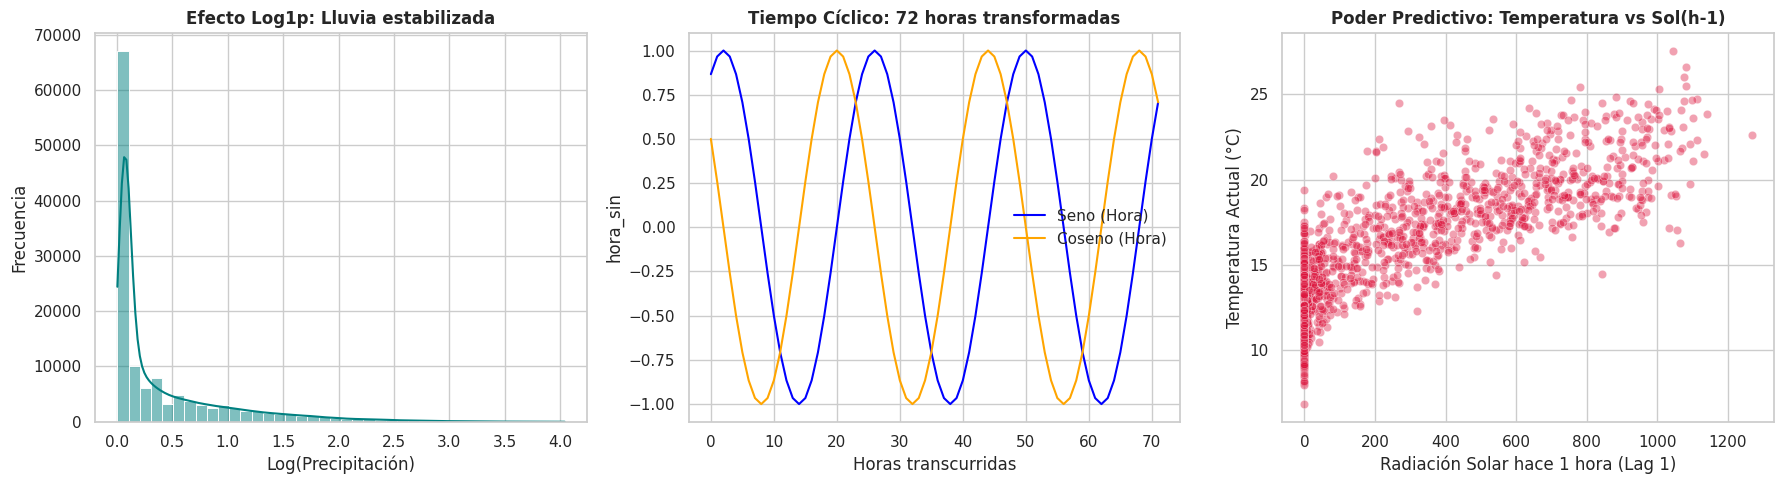


👁️ Muestra de los predictores finales (Head):


,estacion,temperaturaMedia,precipitacion_log,viento_u,radiacionSolar_lag1,hora_sin
0,Belisario,11.15,0.0,0.055888,0.0,0.000000
6,Belisario,11.15,0.0,0.055888,0.0,0.258819
12,Belisario,10.86,0.0,0.466188,0.0,0.500000
18,Belisario,10.87,0.0,0.150607,0.0,0.707107


In [16]:
def auditoria_final_mdt(df_final):
    print("="*80)
    print("  AUDITORÍA VISUAL DE LA MATRIZ DE DATOS DE TRABAJO (MDT)")
    print("="*80)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---------------------------------------------------------
    # 1. El efecto del Logaritmo en la Lluvia
    # ---------------------------------------------------------
    # Filtramos solo donde llovió para ver la campana
    lluvia_real = df_final[df_final['precipitacion'] > 0]

    sns.histplot(lluvia_real['precipitacion_log'], kde=True, color='teal', ax=axes[0], bins=40)
    axes[0].set_title("Efecto Log1p: Lluvia estabilizada", fontweight='bold')
    axes[0].set_xlabel("Log(Precipitación)")
    axes[0].set_ylabel("Frecuencia")

    # ---------------------------------------------------------
    # 2. Los Tensores Cíclicos (Un mes de ejemplo)
    # ---------------------------------------------------------
    # Tomamos solo 72 horas de una estación para ver la onda
    muestra_tiempo = df_final[df_final['estacion'] == df_final['estacion'].iloc[0]].iloc[100:172]

    sns.lineplot(data=muestra_tiempo, x=range(72), y='hora_sin', label='Seno (Hora)', color='blue', ax=axes[1])
    sns.lineplot(data=muestra_tiempo, x=range(72), y='hora_cos', label='Coseno (Hora)', color='orange', ax=axes[1])
    axes[1].set_title("Tiempo Cíclico: 72 horas transformadas", fontweight='bold')
    axes[1].set_xlabel("Horas transcurridas")
    axes[1].legend()

    # ---------------------------------------------------------
    # 3. La memoria térmica (Lag vs Original)
    # ---------------------------------------------------------
    sns.scatterplot(data=df_final.sample(2000, random_state=42),
                    x='radiacionSolar_lag1', y='temperaturaMedia',
                    alpha=0.4, color='crimson', ax=axes[2])
    axes[2].set_title("Poder Predictivo: Temperatura vs Sol(h-1)", fontweight='bold')
    axes[2].set_xlabel("Radiación Solar hace 1 hora (Lag 1)")
    axes[2].set_ylabel("Temperatura Actual (°C)")

    plt.tight_layout()
    plt.show()

    # Mostrar un pedazo de la tabla para ver las columnas reales
    print("\n️ Muestra de los predictores finales (Head):")
    cols_a_mostrar = ['estacion', 'temperaturaMedia', 'precipitacion_log', 'viento_u', 'radiacionSolar_lag1', 'hora_sin']
    display(df_final[cols_a_mostrar].head(4))

# Ejecutamos la auditoría
auditoria_final_mdt(df_final)

* El logaritmo comprimió el skewness
* Con seno y coseno eliminamos el salto artificial de medianoche (de 23:00 a 00:00) y lo convertimos en un ciclo continuo ininterrumpido.
* La nube de puntos ascendente en el gráfico rojo es la prueba irrefutable de la inercia térmica de Quito.
* La previsualización de la tabla nos confirma que el downcasting a float32 sobrevivió a las imputaciones, manteniendo la matriz ultraligera.

## FASE 6: Exportación de la MDT
Guardado de la Matriz de Datos de Trabajo definitiva en formato Parquet. Esta base está lista para ser ingerida por los *DataLoaders* (PyTorch/TensorFlow) en el entrenamiento de las arquitecturas de Deep Learning para la predicción de Temperatura y Precipitación.

In [19]:
def exportar_mdt_final(df_listo, ruta_base, nombre):
    print("="*80)
    print("  FASE 5: EXPORTACIÓN DE LA MATRIZ DE DATOS DE TRABAJO (MDT)")
    print("="*80)

    # Definimos el nombre definitivo del archivo para los modelos
    file_name = f"{ruta_base}{nombre}.parquet"

    # Verificamos los tipos de datos finales antes de guardar
    print("\nEsquema de tensores:")
    display(df_listo.dtypes)

    # Exportación (index=False previene que se guarde el índice si no es necesario)
    df_listo.to_parquet(file_name, compression='snappy', index=False)

    print(f"\n ¡Éxito! MDT exportada correctamente.")
    print(f"  Ruta: {file_name}")
    print(f"  Dimensiones finales: {df_listo.shape[0]:,} filas x {df_listo.shape[1]} columnas")
    print("="*80)

# Ejecutamos la exportación
exportar_mdt_final(df_final, PATH, 'mdt_feature_store_2008')

 💾 FASE 5: EXPORTACIÓN DE LA MATRIZ DE DATOS DE TRABAJO (MDT)

Esquema de tensores:


,0
fechaHora,datetime64[ns]
estacion,category
fecha,object
hora,int32
humedadRelativa,float32
precipitacion,float32
presionBarometrica,float32
radiacionSolar,float32
temperaturaMedia,float32
mes,int32



✅ ¡Éxito! MDT exportada correctamente.
 ➔ Ruta: /content/drive/My Drive/Experimentos/data/mdt_feature_store_2008.parquet
 ➔ Dimensiones finales: 959,760 filas x 23 columnas
